# Accessing Antarctica Cube Data

This notebook is a runnable remote-access demo for the Antarctica data cubes.

The example uses a small Amundsen Sea sector ROI. Change `ROI_CENTER_XY_M` or `ROI_HALF_WIDTH_CELLS` to explore another area. Remote reads still happen at the Zarr chunk level, so keep the ROI inside one chunk-sized area for quick laptop runs.


## Setup

The constants below define the remote Zarr stores, the example ROI, and the
sampling used for velocity arrows. All following sections use named variables
rather than passing dictionaries around.


In [58]:
import numpy as np
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-1_600_000.0, -350_000.0)
ROI_HALF_WIDTH_CELLS = 1900
VELOCITY_VECTOR_STRIDE = 90
TEMPERATURE_DEPTH_TARGET_M = 1000

In [62]:
cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr",
]

ds = xr.open_mfdataset(cube_paths, engine="zarr", chunks={}, compat="no_conflicts")

ds


<xarray.Dataset> Size: 7TB
Dimensions:                                       (y: 49158, x: 57358,
                                                   depth: 91, time_period: 27,
                                                   time: 48)
Coordinates:
  * y                                             (y) float32 197kB -2.458e+0...
  * x                                             (x) float32 229kB -2.868e+0...
  * depth                                         (depth) int16 182B 0 ... 4500
  * time_period                                   (time_period) int64 216B 0 ...
  * time                                          (time) datetime64[ns] 384B ...
    spatial_ref                                   int64 8B 0
Data variables: (12/40)
    englacial_temp_profile_quality_flag           (y, x) float16 6GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    englacial_temp_profile_tice                   (depth, y, x) float16 513GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_basin_id             (y, x) float32 11GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    surface_elevation_change_cell_end_times       (time_period, y, x) float32 305GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_cell_start_times     (time_period, y, x) float32 305GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_end_time             (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                            ...
    ice_sheet_surface_velocity_easting_stddev     (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    ice_sheet_surface_velocity_magnitude          (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    ice_sheet_surface_velocity_measurement_count  (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    ice_sheet_surface_velocity_northing           (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    ice_sheet_surface_velocity_northing_stddev    (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    ice_sheet_surface_velocity_vertical           (time, y, x) float32 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>

## Select A Small Region Of Interest

The land/ice cubes share the same `y, x` grid. The helper below snaps the
requested EPSG:3031 point to the nearest cube cell and builds one integer ROI
slice that is reused for every cube.


In [63]:
x_index = int(np.abs(ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)

small = ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})

small


<xarray.Dataset> Size: 35GB
Dimensions:                                       (y: 3801, x: 3801, depth: 91,
                                                   time_period: 27, time: 48)
Coordinates:
  * y                                             (y) float32 15kB -5.4e+05 ....
  * x                                             (x) float32 15kB -1.79e+06 ...
  * depth                                         (depth) int16 182B 0 ... 4500
  * time_period                                   (time_period) int64 216B 0 ...
  * time                                          (time) datetime64[ns] 384B ...
    spatial_ref                                   int64 8B 0
Data variables: (12/40)
    englacial_temp_profile_quality_flag           (y, x) float16 29MB dask.array<chunksize=(3801, 3801), meta=np.ndarray>
    englacial_temp_profile_tice                   (depth, y, x) float16 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    surface_elevation_change_basin_id             (y, x) float32 58MB dask.array<chunksize=(3801, 3801), meta=np.ndarray>
    surface_elevation_change_cell_end_times       (time_period, y, x) float32 2GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    surface_elevation_change_cell_start_times     (time_period, y, x) float32 2GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    surface_elevation_change_end_time             (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                            ...
    ice_sheet_surface_velocity_easting_stddev     (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    ice_sheet_surface_velocity_magnitude          (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    ice_sheet_surface_velocity_measurement_count  (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    ice_sheet_surface_velocity_northing           (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    ice_sheet_surface_velocity_northing_stddev    (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>
    ice_sheet_surface_velocity_vertical           (time, y, x) float32 3GB dask.array<chunksize=(1, 3801, 3801), meta=np.ndarray>

## Plot 1: Bedrock Topography And Thickness Above Flotation

This reproduces the bedrock-topography use case on the remote cube. It combines
BedMachine-style `bed`, `thickness`, and `mask` variables to estimate thickness
above flotation for grounded marine ice. Low values identify ice that is closer
to flotation.


[########################################] | 100% Completed | 15.00 s


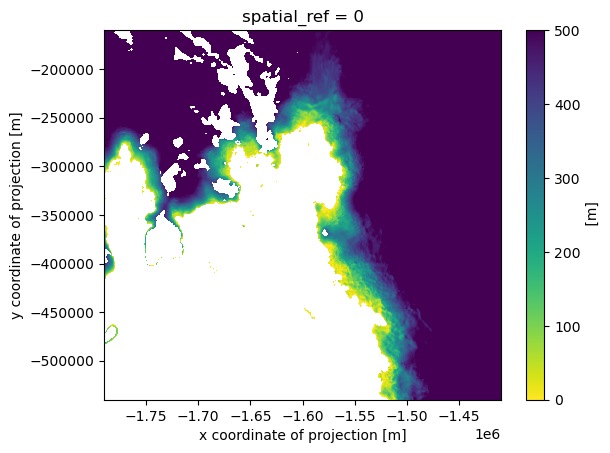

In [64]:
rho_ice = 917.0
rho_water = 1027.0

bed = small["bedrock_topography_bed"]
thickness = small["bedrock_topography_thickness"]
mask = small["bedrock_topography_mask"]

flotation_thickness = xr.where(bed < 0, -(rho_water / rho_ice) * bed, 0)
taf = (thickness - flotation_thickness).where((mask == 2) & (bed < 0)).clip(0, 500)

with ProgressBar():
    taf = taf.compute()

taf.plot(cmap="viridis_r", vmin=0, vmax=500)


## Plot 2: Ice-Shelf Basal Melt Rate

The basal-melt workflow is available as a raster layer in the combined cube. This
plot shows the melt-rate field for the same ROI. The original shelf-name polygon
time series is not part of these raster cubes, but the gridded melt-rate field is
ready for spatial overlay and small-area statistics.


[########################################] | 100% Completed | 845.57 ms


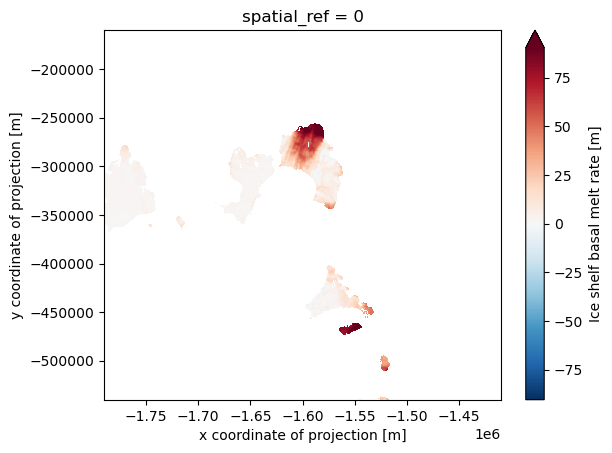

In [65]:
basal_melt = small["ice_shelf_basal_melt_rate"]

with ProgressBar():
    basal_melt = basal_melt.compute()

basal_melt.plot(cmap="RdBu_r", robust=True)


## Plot 3: Surface Elevation Change

The SEC cube stores gridded surface-elevation-change rates by time period. This
example takes the latest period, masks to grounded ice, converts metres to
millimetres, and plots the spatial fingerprint of elevation gain or loss.


[########################################] | 100% Completed | 1.35 sms


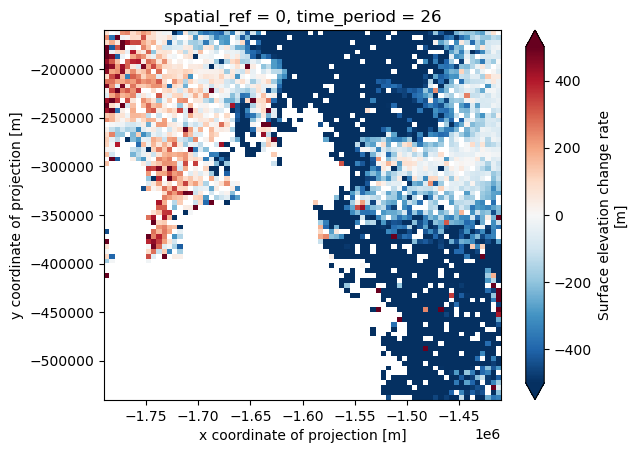

In [66]:
sec_rate = small["surface_elevation_change_rate"].isel(time_period=-1) * 1000
sec_grounded = small["surface_elevation_change_surface_type"] == 2
sec_rate = sec_rate.where(sec_grounded)

with ProgressBar():
    sec_rate = sec_rate.compute()

sec_rate.plot(cmap="RdBu_r", vmin=-500, vmax=500)


## Plot 4: Englacial Temperature At A Selected Depth

The old temperature notebook reprojected a non-regular source product. In the
remote cube, ice temperature is already on the shared EPSG:3031 grid. This plot
selects the depth nearest `TEMPERATURE_DEPTH_TARGET_M` and converts Kelvin to
Celsius for display.


[########################################] | 100% Completed | 312.15 ms


/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:107: RuntimeWarning: overflow encountered in cast
  get_virtual_index=lambda n, quantiles: (n - 1) * quantiles,
/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4750: RuntimeWarning: overflow encountered in cast
  indexes_above_bounds = virtual_indexes >= valid_values_count - 1
/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in scalar multiply
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


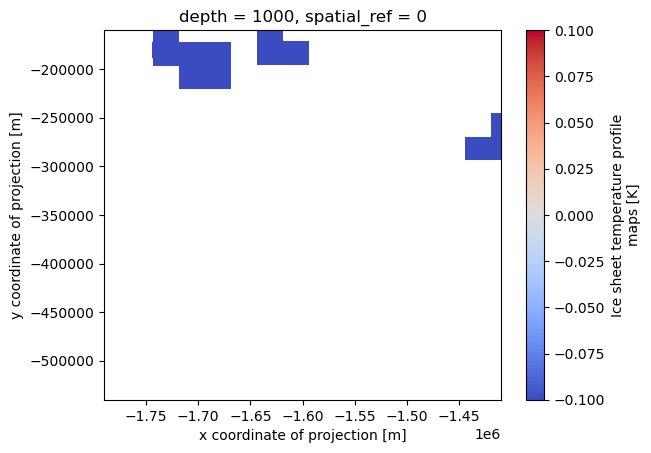

In [68]:
depth_index = int(np.abs(small["depth"].values - TEMPERATURE_DEPTH_TARGET_M).argmin())
ice_temp_c = small["englacial_temp_profile_tice"].isel(depth=depth_index) - 273.15

with ProgressBar():
    ice_temp_c = ice_temp_c.compute()

ice_temp_c.plot(cmap="coolwarm", robust=True)


## Plot 5: Calving-Front Mask Change

The calving-front product is transformed from time-evolving vector polygons into
a raster mask stack. This plot compares the first and last available masks in
the ROI, highlighting where the binary mask changed through time.


[########################################] | 100% Completed | 19.42 s
[########################################] | 100% Completed | 1.88 ss


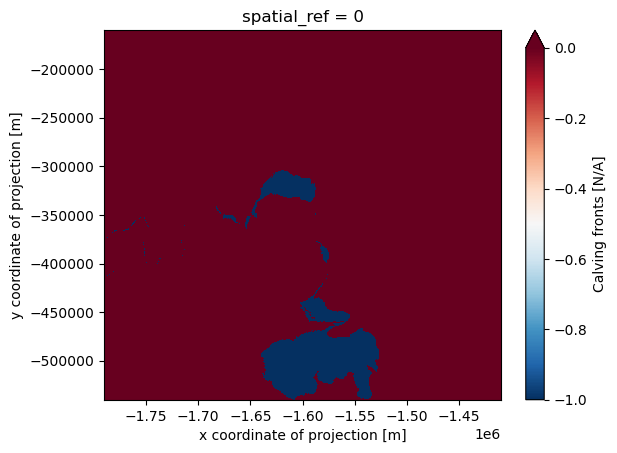

In [69]:
calving = small["calving_fronts"]

with ProgressBar():
    calving_time = calving.notnull().any(("x", "y")).compute()

calving = calving.isel(time=calving_time.values)
calving_change = calving.isel(time=-1) - calving.isel(time=0)

with ProgressBar():
    calving_change = calving_change.compute()

calving_change.plot(cmap="RdBu_r", robust=True)


## Plot 6: Grounding Lines And Lake Masks

The groundline, subglacial-lake, and supraglacial-lake workflows are available
as raster masks in the combined cube. This plot combines them into one class-code
image for a compact overview: `1` marks supraglacial lakes/channels, `2` marks
subglacial lakes, and `4` marks grounding-line pixels. Sums indicate overlap.


[########################################] | 100% Completed | 521.19 ms


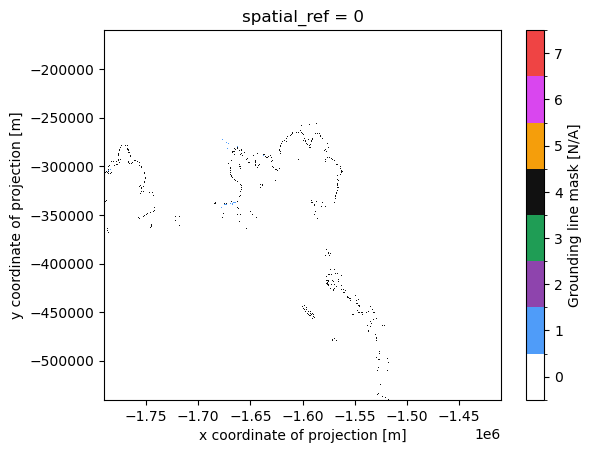

In [70]:
mask_code = (
    (small["supra_glacial_lakes_mask"] > 0).astype("uint8")
    + 2 * (small["subglacial_lakes_mask"] > 0).astype("uint8")
    + 4 * (small["groundlines_mask"] > 0).astype("uint8")
)

with ProgressBar():
    mask_code = mask_code.compute()

mask_cmap = ListedColormap(["white", "#4f9cf9", "#8e44ad", "#1f9d55", "#111111", "#f59e0b", "#d946ef", "#ef4444"])
mask_norm = BoundaryNorm(np.arange(-0.5, 8.5), mask_cmap.N)

mask_code.plot(cmap=mask_cmap, norm=mask_norm, cbar_kwargs={"ticks": range(8)})


## Plot 7: Ice Velocity Vectors Over Basal Melt

The velocity cube provides easting, northing, and magnitude variables on the same
remote grid. This section samples the latest time step coarsely for arrows and
plots those vectors over the basal-melt raster computed earlier.


[########################################] | 100% Completed | 850.90 ms
[########################################] | 100% Completed | 11.30 ss
[########################################] | 100% Completed | 13.33 s


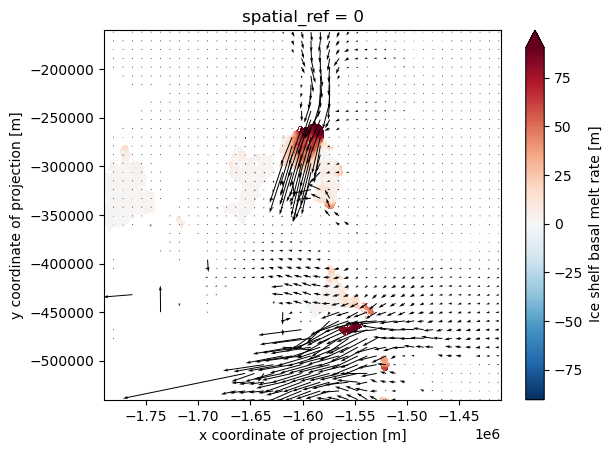

In [71]:
stride = VELOCITY_VECTOR_STRIDE

background = small["ice_shelf_basal_melt_rate"]
u = small["ice_sheet_surface_velocity_easting"].isel(time=-1, y=slice(None, None, stride), x=slice(None, None, stride))
v = small["ice_sheet_surface_velocity_northing"].isel(time=-1, y=slice(None, None, stride), x=slice(None, None, stride))
with ProgressBar():
    background = background.compute()
    u = u.compute()
    v = v.compute()

X, Y = np.meshgrid(u["x"].values, u["y"].values)
ax = background.plot(cmap="RdBu_r", robust=True).axes
ax.quiver(X, Y, u.values, v.values, width=0.0025)
